<a href="https://colab.research.google.com/github/Sanath-cmd/Internship_ITT/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
import plotly.express as px
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV

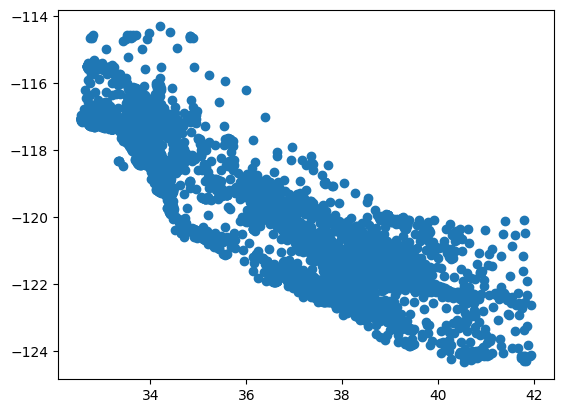

In [27]:

df = pd.read_csv("/content/drive/My Drive/housing.csv")
lat_long = df[['latitude', 'longitude']]
lat, longg =df['latitude'], df['longitude']
plt.scatter(lat,longg)

In [28]:
X = lat_long.to_numpy()
X

array([[  37.88, -122.23],
       [  37.86, -122.22],
       [  37.85, -122.24],
       ...,
       [  39.43, -121.22],
       [  39.43, -121.32],
       [  39.37, -121.24]])

In [44]:
model = DBSCAN(eps= 0.1, min_samples= 20)
model.fit(X)
df['cluster'] = model.labels_
df['cluster'].value_counts()

,count
cluster,
13,8852
0,4729
22,1580
-1,1312
18,863
17,796
6,561
9,231
32,192


In [45]:
px.scatter(x = longg, y = lat, color = df['cluster'])

In [46]:
silhouette_score(X, df['cluster'])

np.float64(0.3031094624448799)

In [43]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

best_score = -1
best_params = None

for eps in [0.01, 0.1, 0.5, 0.75, 1, 1.2, 1.5, 1.75, 2, 5, 10]:
    for min_samples in [5, 10, 15, 20, 50, 100, 150, 200]:

        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)


        unique_clusters = set(labels)
        unique_clusters.discard(-1)#removes noise


        if len(unique_clusters) >= 2:
            score = silhouette_score(X, labels)

            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)

print("Best score:", best_score)
print("Best params:", best_params)


Best score: 0.3031094624448799
Best params: (0.1, 20)
